# 05 — Geographic Concentration Analysis
**Ubon Ratchathani Constituency 10** | Data Science Project 2025/2

Analyzing how votes are geographically distributed:
1. Which candidates have concentrated vs spread-out support
2. Tambon-level winner map
3. Stronghold detection — tambons where a candidate dominates (>50%, >60%, >70%)
4. Competitive tambons — where the margin is tight

## 0 · Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

RAW  = Path('../data-final')
OUT  = Path('../data-processed/5')
OUT1  = Path('../data-processed/1')
FIG  = Path('../figures')
FIG.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

const_by_tambon = pd.read_csv(OUT1 / 'constituency_by_tambon.csv')
cand_map        = pd.read_csv(OUT1 / 'candidate_mapping.csv')

color_map = dict(zip(cand_map['party_name'], cand_map['color_hex']))
cand_color_map = dict(zip(cand_map['candidate_name'], cand_map['color_hex']))

print('Loaded OK')
print(f'Tambons: {const_by_tambon["tambon"].nunique()}')
print(f'Amphoes: {const_by_tambon["amphoe"].nunique()}')

Loaded OK
Tambons: 23
Amphoes: 5


In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Use a font that supports Thai — try system fonts first
thai_fonts = ['Tahoma', 'Arial Unicode MS', 'Noto Sans Thai', 'TH Sarabun New', 'FreeSans']

available = [f.name for f in fm.fontManager.ttflist]
chosen = next((f for f in thai_fonts if f in available), None)

if chosen:
    plt.rcParams['font.family'] = chosen
    print(f'Using font: {chosen}')
else:
    print('No Thai font found — labels may be garbled')
    print('Available fonts sample:', available[:10])

Using font: Tahoma


## 1 · Vote Share per Candidate per Tambon

In [2]:
# Total votes per tambon (sum across all candidates)
tambon_total = (
    const_by_tambon
    .groupby(['amphoe', 'tambon'])['score']
    .sum()
    .reset_index()
    .rename(columns={'score': 'tambon_total'})
)

df = const_by_tambon.merge(tambon_total, on=['amphoe', 'tambon'])
df['vote_share_%'] = (df['score'] / df['tambon_total'] * 100).round(2)

print(df[['amphoe', 'tambon', 'candidate_name', 'party_name', 'score', 'vote_share_%']].head(6).to_string(index=False))

        amphoe         tambon          candidate_name     party_name  score  vote_share_%
ล่วงหน้านอกเขต ล่วงหน้านอกเขต          นายเกษม ฉิมพลี      ภูมิใจไทย    301          3.95
ล่วงหน้านอกเขต ล่วงหน้านอกเขต    นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   4659         61.09
ล่วงหน้านอกเขต ล่วงหน้านอกเขต       นายวัชรพล เชื้อคง       เพื่อไทย    600          7.87
ล่วงหน้านอกเขต ล่วงหน้านอกเขต นางสาวมิลิณ กำเนิดสิงห์   พลังประชารัฐ     66          0.87
ล่วงหน้านอกเขต ล่วงหน้านอกเขต    นายสิโรตม์ แสนทวีสุข        ประชาชน   1979         25.95
ล่วงหน้านอกเขต ล่วงหน้านอกเขต            นายยิ่ง ภูผา   ประชาธิปัตย์     21          0.28


## 2 · Winner per Tambon

In [3]:
winner_per_tambon = (
    df.sort_values('score', ascending=False)
    .groupby(['amphoe', 'tambon'])
    .first()
    .reset_index()
    [['amphoe', 'tambon', 'candidate_name', 'party_name', 'color_hex',
      'score', 'tambon_total', 'vote_share_%']]
    .sort_values(['amphoe', 'tambon'])
)

print('=== Winner per Tambon ===')
print(winner_per_tambon[['amphoe', 'tambon', 'candidate_name', 'party_name', 'score', 'vote_share_%']]
      .to_string(index=False))

=== Winner per Tambon ===
          amphoe          tambon       candidate_name     party_name  score  vote_share_%
  ล่วงหน้านอกเขต  ล่วงหน้านอกเขต นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   4659         61.09
อำเภอทุ่งศรีอุดม     ตำบลกุดเรือ นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   2389         81.70
อำเภอทุ่งศรีอุดม      ตำบลนาห่อม นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   1554         78.64
อำเภอทุ่งศรีอุดม      ตำบลนาเกษม นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   1957         75.44
อำเภอทุ่งศรีอุดม     ตำบลหนองอ้ม นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   1919         76.79
อำเภอทุ่งศรีอุดม    ตำบลโคกชำแระ นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   2317         86.26
    อำเภอน้ำขุ่น    ตำบลขี้เหล็ก นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   3130         83.82
    อำเภอน้ำขุ่น       ตำบลตาเกา นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   1739         92.16
    อำเภอน้ำขุ่น    ตำบลโคกสะอาด นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   2676         91.46
    อำเภอน้ำขุ่น     ตำบลไพบูลย์ นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   262

In [4]:
# Summary: how many tambons each candidate won
tambon_wins = (
    winner_per_tambon
    .groupby(['candidate_name', 'party_name'])
    .agg(tambons_won=('tambon', 'count'),
         total_votes_in_won_tambons=('score', 'sum'))
    .reset_index()
    .sort_values('tambons_won', ascending=False)
)
print('\n=== Tambons Won per Candidate ===')
print(tambon_wins.to_string(index=False))


=== Tambons Won per Candidate ===
      candidate_name     party_name  tambons_won  total_votes_in_won_tambons
นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง           22                       59991
   นายวัชรพล เชื้อคง       เพื่อไทย            1                         660


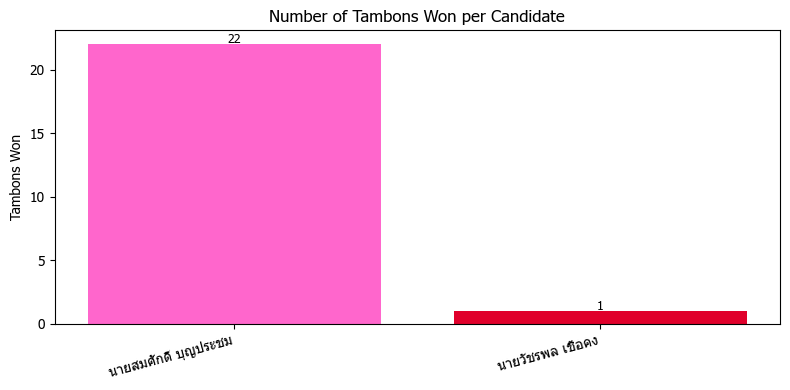

In [7]:
# Bar chart — tambons won
fig, ax = plt.subplots(figsize=(8, 4))
colors = [cand_color_map.get(c, '#cccccc') for c in tambon_wins['candidate_name']]
ax.bar(tambon_wins['candidate_name'], tambon_wins['tambons_won'], color=colors)
ax.set_ylabel('Tambons Won')
ax.set_title('Number of Tambons Won per Candidate')
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(tambon_wins['tambons_won']):
    ax.text(i, v + 0.1, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG / 'geo_tambons_won.png', dpi=150)
plt.show()

## 3 · Heatmap — Vote Share per (Tambon × Candidate)

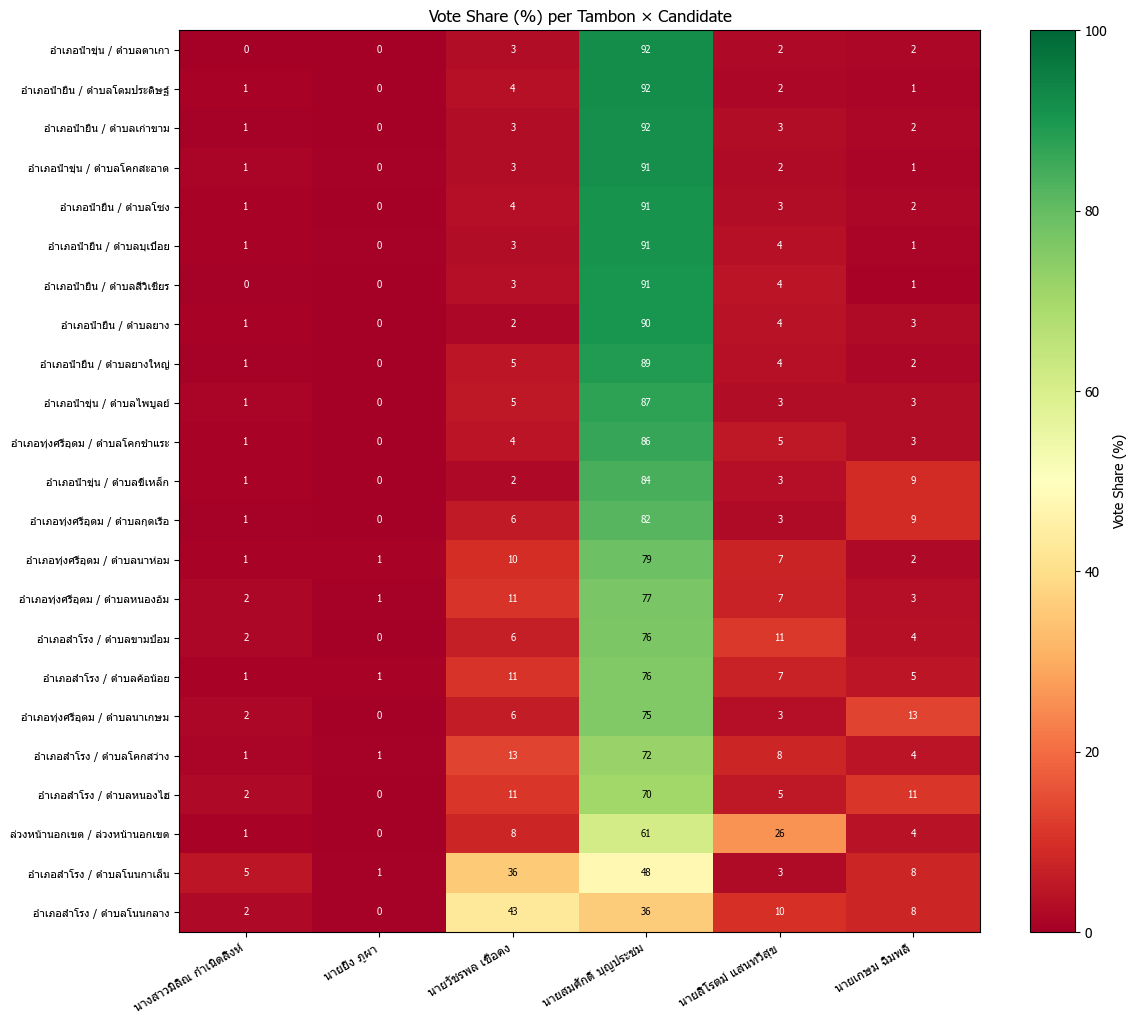

In [8]:
pivot = df.pivot_table(
    index=['amphoe', 'tambon'],
    columns='candidate_name',
    values='vote_share_%',
    aggfunc='sum'
).fillna(0)

# Sort by winner's share descending
winner_col = tambon_wins.iloc[0]['candidate_name']
pivot = pivot.sort_values(winner_col, ascending=False)

fig, ax = plt.subplots(figsize=(12, max(6, len(pivot) * 0.45)))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{a} / {t}" for a, t in pivot.index], fontsize=8)

# Annotate values
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                    fontsize=7, color='black' if 20 < val < 80 else 'white')

plt.colorbar(im, ax=ax, label='Vote Share (%)')
ax.set_title('Vote Share (%) per Tambon × Candidate')
plt.tight_layout()
plt.savefig(FIG / 'geo_heatmap_tambon_cand.png', dpi=150)
plt.show()

## 4 · Stronghold Detection

Tambons where the winner dominates by threshold.

In [9]:
thresholds = [50, 60, 70]

print('=== Stronghold Tambons per Candidate ===\n')
for thresh in thresholds:
    strongholds = winner_per_tambon[winner_per_tambon['vote_share_%'] >= thresh]
    counts = strongholds.groupby(['candidate_name', 'party_name']).size().reset_index(name='tambons')
    print(f'--- Threshold ≥ {thresh}% ---')
    print(counts.to_string(index=False))
    print()

=== Stronghold Tambons per Candidate ===

--- Threshold ≥ 50% ---
      candidate_name     party_name  tambons
นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง       21

--- Threshold ≥ 60% ---
      candidate_name     party_name  tambons
นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง       21

--- Threshold ≥ 70% ---
      candidate_name     party_name  tambons
นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง       20



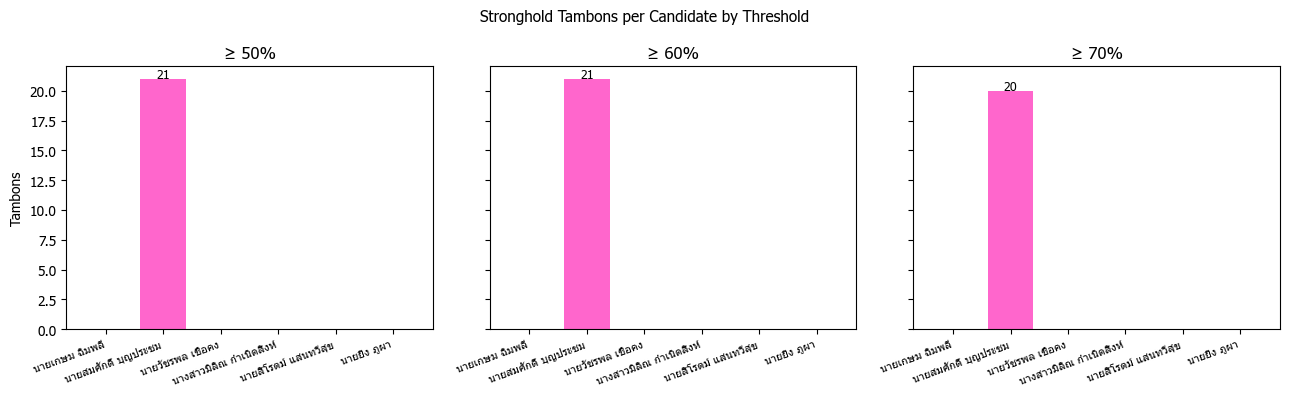

In [10]:
# Visualize: stacked bar of stronghold counts per threshold per candidate
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, thresh in zip(axes, thresholds):
    strongholds = winner_per_tambon[winner_per_tambon['vote_share_%'] >= thresh]
    counts = strongholds.groupby('candidate_name').size().reset_index(name='count')

    # Fill missing candidates with 0
    all_cands = cand_map['candidate_name'].tolist()
    counts = pd.DataFrame({'candidate_name': all_cands}).merge(counts, on='candidate_name', how='left').fillna(0)
    counts['count'] = counts['count'].astype(int)
    colors = [cand_color_map.get(c, '#cccccc') for c in counts['candidate_name']]

    ax.bar(counts['candidate_name'], counts['count'], color=colors)
    ax.set_title(f'≥ {thresh}%')
    ax.set_ylabel('Tambons' if thresh == 50 else '')
    for i, v in enumerate(counts['count']):
        if v > 0:
            ax.text(i, v + 0.05, str(v), ha='center', fontsize=9)
    plt.sca(ax)
    plt.xticks(rotation=20, ha='right', fontsize=8)

fig.suptitle('Stronghold Tambons per Candidate by Threshold', fontsize=11)
plt.tight_layout()
plt.savefig(FIG / 'geo_strongholds.png', dpi=150)
plt.show()

## 5 · Competitive Tambons

Tambons where the margin between 1st and 2nd is tight (< 10pp).
These are the battleground areas.

In [11]:
def tambon_margin(group):
    sorted_rows = group.sort_values('score', ascending=False)
    if len(sorted_rows) < 2:
        return None
    first  = sorted_rows.iloc[0]
    second = sorted_rows.iloc[1]
    total  = group['score'].sum()
    return pd.Series({
        'winner':          first['candidate_name'],
        'winner_party':    first['party_name'],
        'winner_share_%':  round(first['score'] / total * 100, 2),
        'runner_up':       second['candidate_name'],
        'runner_up_share_%': round(second['score'] / total * 100, 2),
        'margin_pp':       round((first['score'] - second['score']) / total * 100, 2),
        'total_votes':     total,
    })

margins = (
    df.groupby(['amphoe', 'tambon'])
    .apply(tambon_margin)
    .reset_index()
    .sort_values('margin_pp')
)

competitive = margins[margins['margin_pp'] < 10]
print(f'Competitive tambons (margin < 10pp): {len(competitive)}')
print(competitive[['amphoe', 'tambon', 'winner', 'winner_share_%',
                    'runner_up', 'runner_up_share_%', 'margin_pp']].to_string(index=False))

Competitive tambons (margin < 10pp): 1
    amphoe      tambon            winner  winner_share_%            runner_up  runner_up_share_%  margin_pp
อำเภอสำโรง ตำบลโนนกลาง นายวัชรพล เชื้อคง           43.19 นายสมศักดิ์ บุญประชม              36.13       7.07


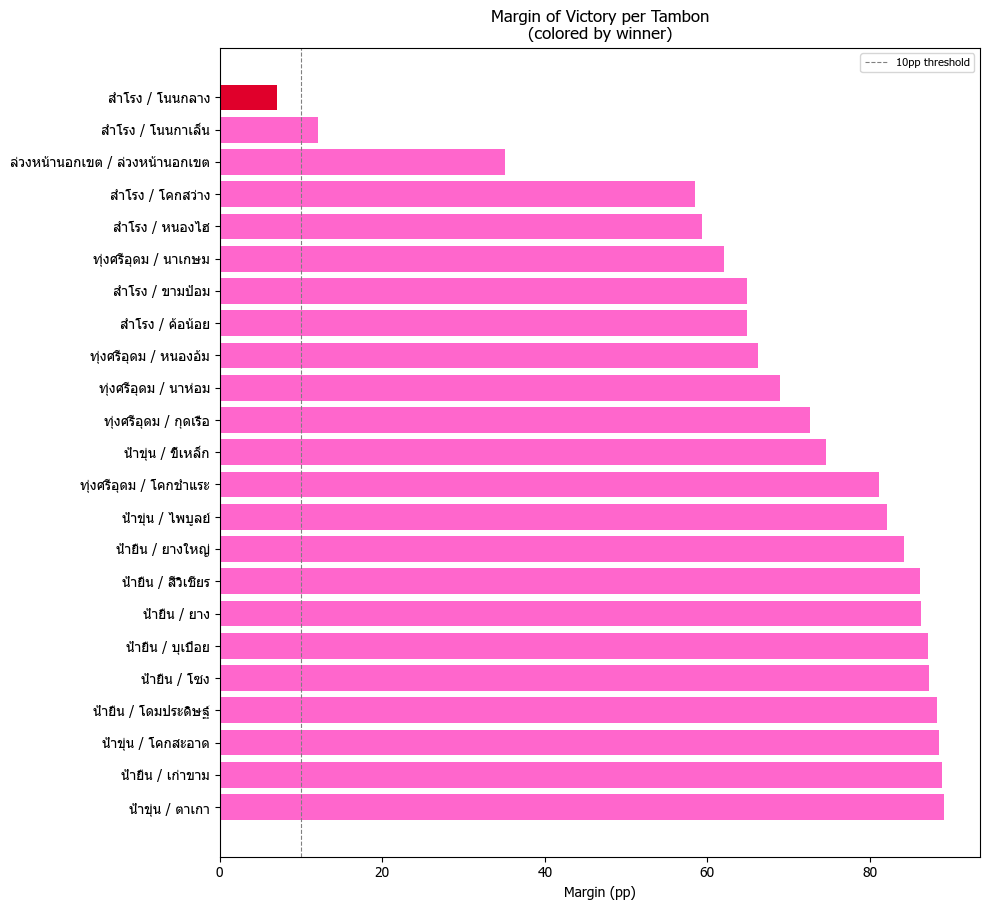

In [12]:
# All tambons ranked by margin
fig, ax = plt.subplots(figsize=(10, max(5, len(margins) * 0.4)))

bar_colors = [cand_color_map.get(w, '#cccccc') for w in margins['winner']]
ax.barh(
    [f"{r['amphoe'].replace('อำเภอ','')} / {r['tambon'].replace('ตำบล','')}"
     for _, r in margins.iterrows()],
    margins['margin_pp'],
    color=bar_colors
)
ax.axvline(10, color='gray', linestyle='--', linewidth=0.8, label='10pp threshold')
ax.set_xlabel('Margin (pp)')
ax.set_title('Margin of Victory per Tambon\n(colored by winner)')
ax.legend(fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG / 'geo_margin_tambon.png', dpi=150)
plt.show()

## 6 · Geographic Concentration (Gini-style)

For each candidate, how concentrated are their votes?
Compute share of votes coming from their top 3 tambons.
High concentration = relies heavily on a few tambons.
Low concentration = support spread evenly across all tambons.

In [13]:
concentration = []

for _, cand in cand_map.iterrows():
    cname = cand['candidate_name']
    cdf   = df[df['candidate_name'] == cname].sort_values('score', ascending=False)
    total = cdf['score'].sum()
    if total == 0:
        continue
    top3_share = cdf.head(3)['score'].sum() / total * 100
    top1_share = cdf.head(1)['score'].sum() / total * 100
    concentration.append({
        'candidate_name': cname,
        'party_name':     cand['party_name'],
        'color_hex':      cand['color_hex'],
        'top1_tambon':    cdf.iloc[0]['tambon'],
        'top1_share_%':   round(top1_share, 2),
        'top3_share_%':   round(top3_share, 2),
        'total_votes':    total,
    })

conc_df = pd.DataFrame(concentration).sort_values('top3_share_%', ascending=False)
print('=== Vote Concentration (Top 3 Tambons) ===')
print(conc_df[['candidate_name', 'party_name', 'top1_tambon',
               'top1_share_%', 'top3_share_%', 'total_votes']].to_string(index=False))

=== Vote Concentration (Top 3 Tambons) ===
         candidate_name     party_name     top1_tambon  top1_share_%  top3_share_%  total_votes
   นายสิโรตม์ แสนทวีสุข        ประชาชน  ล่วงหน้านอกเขต         40.81         50.86         4849
      นายวัชรพล เชื้อคง       เพื่อไทย   ตำบลโนนกาเล็น         17.62         39.93         5647
         นายเกษม ฉิมพลี      ภูมิใจไทย      ตำบลนาเกษม         11.19         32.53         3111
นางสาวมิลิณ กำเนิดสิงห์   พลังประชารัฐ   ตำบลโนนกาเล็น         15.45         29.65          887
           นายยิ่ง ภูผา   ประชาธิปัตย์     ตำบลค้อน้อย         12.94         29.02          255
   นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง ตำบลโดมประดิษฐ์         10.99         25.63        60543


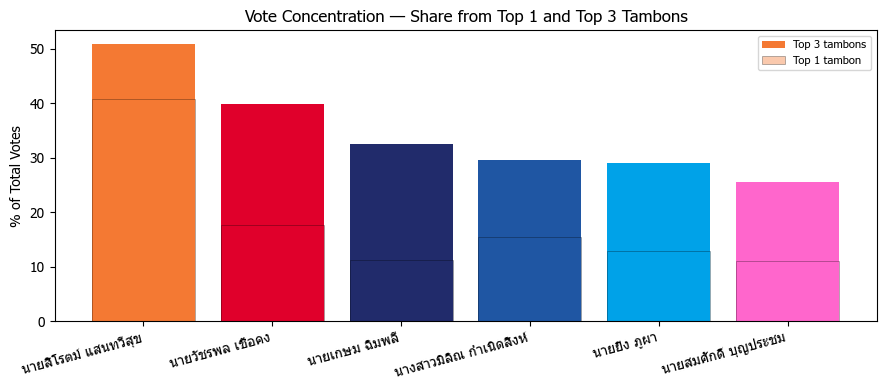

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = conc_df['color_hex'].tolist()
ax.bar(conc_df['candidate_name'], conc_df['top3_share_%'], color=colors, label='Top 3 tambons')
ax.bar(conc_df['candidate_name'], conc_df['top1_share_%'], color=colors, alpha=0.4,
       edgecolor='black', linewidth=0.5, label='Top 1 tambon')
ax.set_ylabel('% of Total Votes')
ax.set_title('Vote Concentration — Share from Top 1 and Top 3 Tambons')
ax.legend(fontsize=8)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIG / 'geo_concentration.png', dpi=150)
plt.show()

## 7 · Export

In [15]:
winner_per_tambon.to_csv(OUT / 'geo_winner_tambon.csv',    index=False, encoding='utf-8-sig')
margins.to_csv(OUT / 'geo_margin_tambon.csv',              index=False, encoding='utf-8-sig')
conc_df.to_csv(OUT / 'geo_concentration.csv',              index=False, encoding='utf-8-sig')

print('Exported OK')

Exported OK


## Summary

| File | Description |
|------|-------------|
| `geo_winner_tambon.csv` | Winner + vote share per tambon |
| `geo_margin_tambon.csv` | Margin of victory per tambon (sorted) |
| `geo_concentration.csv` | Vote concentration (top 1 / top 3 tambon share) |

**Next:** `06_comparison_2566.ipynb` — Compare 2566 vs 2569 results